<a href="https://colab.research.google.com/github/Glaze0/Assignment/blob/main/18_SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


**Prob Statement:** a bank's note-sorting machine scans every note that comes in. For each scan, software reduces the image texture to four numbers. The machine must decide: **genuine or forged?**


**About the data:** 1,372 real banknotes, photographed and passed through a wavelet transform (a standard image-texture tool). Each note gives four numbers:

| Column | What it measures |
|---|---|
| `variance` | how much the image texture varies |
| `skewness` | how lopsided that variation is |
| `kurtosis` | how "peaked" it is |
| `entropy` | how disordered the texture is |
| **`forged`** | **target: 1 = fake, 0 = genuine** |


In [ ]:
!gdown 1rjj_Cgkf_Jlaa884W474cPaiaqJYDdRS

Downloading...
From: https://drive.google.com/uc?id=1rjj_Cgkf_Jlaa884W474cPaiaqJYDdRS
To: /content/banknotes.csv
100% 43.4k/43.4k [00:00<00:00, 48.5MB/s]


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.metrics import accuracy_score

In [ ]:
notes = pd.read_csv("banknotes.csv")

print("notes:", len(notes), "| forged share:", round(notes['forged'].mean(), 3))
notes.head()

notes: 1372 | forged share: 0.445


,variance,skewness,kurtosis,entropy,forged
0,3.6216,8.6661,-2.8073,-0.4470,0
1,4.5459,8.1674,-2.4586,-1.4621,0
2,3.8660,-2.6383,1.9242,0.1064,0
3,3.4566,9.5228,-4.0112,-3.5944,0
4,0.3292,-4.4552,4.5718,-0.9888,0


In [ ]:
X = notes[["variance", "skewness"]]
y = notes["forged"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
scaler = StandardScaler()
scaler.fit(X_train)   # mu, sig for each column
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

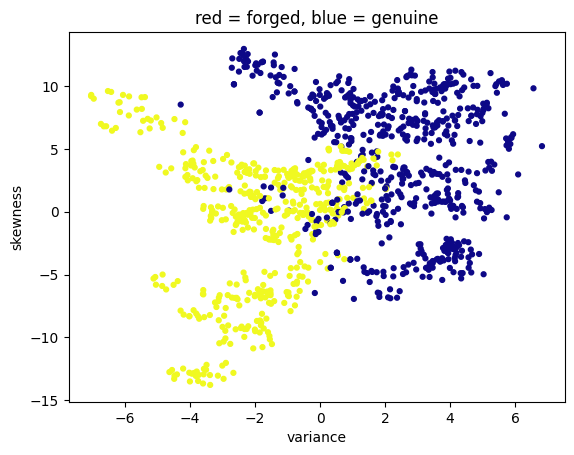

In [ ]:
plt.scatter(X_train["variance"], X_train["skewness"], c= y_train, cmap="plasma", s=12)

plt.xlabel("variance")
plt.ylabel("skewness")
plt.title("red = forged, blue = genuine")
plt.show();

In [ ]:
def report(model):
    y_pred = model.predict(X_test_scaled)
    missed = ((y_pred == 0) & (y_test == 1)).sum()
    print("accuracy:", round(accuracy_score(y_test, y_pred), 3), "| fakes missed:", missed, "of", y_test.sum())

In [ ]:
linear = SVC(C=1.0, kernel='linear')  # linear model
linear.fit(X_train_scaled, y_train)
report(linear)

# class_weight

accuracy: 0.876 | fakes missed: 15 of 122


In [ ]:
def plot_svm(model, title):
    display = DecisionBoundaryDisplay.from_estimator(
        model, X_train_scaled, response_method="decision_function",
        plot_method="contour", levels=[-1, 0, 1], colors="black", linestyles=["--", "-", "--"])
    display.ax_.scatter(X_train_scaled[:, 0], X_train_scaled[:, 1], c=y_train, cmap="coolwarm", s=10, alpha=0.6)
    display.ax_.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1],
                        s=45, facecolors="none", edgecolors="black", linewidths=0.6)
    display.ax_.set(xlabel="variance (scaled)", ylabel="skewness (scaled)", title=title)
    plt.show()

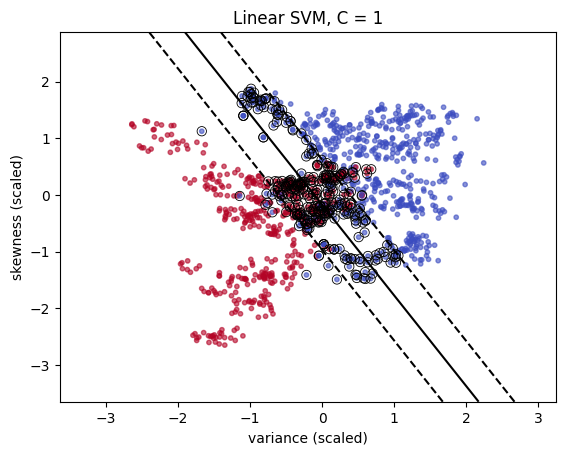

In [ ]:
plot_svm(linear, "Linear SVM, C = 1")

accuracy: 0.862 | fakes missed: 29 of 122


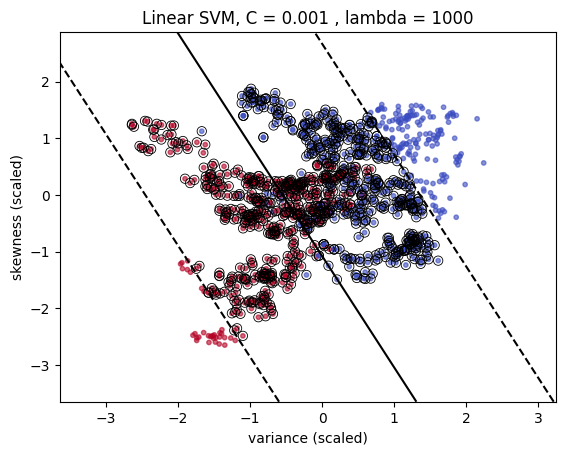

In [ ]:
linear = SVC(C=0.001, kernel='linear')  # linear model
linear.fit(X_train_scaled, y_train)
report(linear)

plot_svm(linear, "Linear SVM, C = 0.001 , lambda = 1000")

In [ ]:
# Support vectors : black border.
# - they contribute to the error/penalty/line formation
#     - either in wrong zone.
#     - in no man's land ( inside margin )

accuracy: 0.876 | fakes missed: 15 of 122


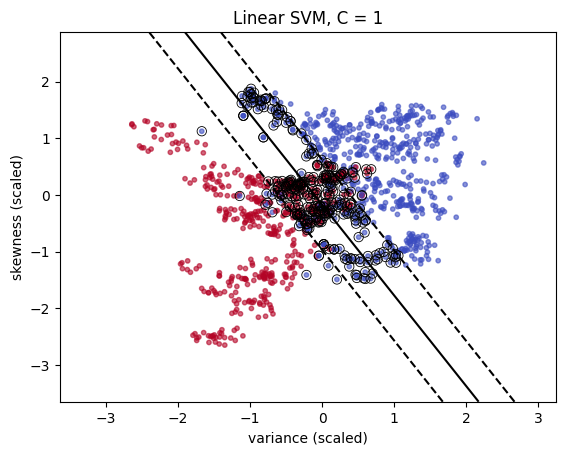

In [ ]:
linear = SVC(C=1, kernel='linear')  # linear model
linear.fit(X_train_scaled, y_train)
report(linear)

plot_svm(linear, "Linear SVM, C = 1")

In [ ]:
linear.support_

array([   6,   11,   18,   21,   35,   40,   41,   42,   50,   54,   58,
         91,   94,  105,  108,  119,  133,  138,  143,  148,  164,  171,
        173,  179,  183,  190,  195,  208,  222,  224,  239,  242,  253,
        255,  258,  266,  281,  282,  284,  286,  289,  292,  297,  308,
        316,  317,  318,  327,  333,  349,  361,  365,  373,  375,  377,
        387,  389,  404,  436,  438,  441,  450,  453,  456,  460,  462,
        470,  476,  477,  480,  491,  500,  509,  515,  534,  546,  552,
        581,  585,  588,  591,  598,  602,  605,  611,  616,  623,  626,
        635,  645,  650,  664,  666,  670,  674,  697,  698,  702,  709,
        712,  713,  715,  727,  732,  742,  749,  755,  757,  759,  787,
        789,  793,  796,  798,  802,  825,  826,  839,  845,  848,  854,
        856,  868,  870,  872,  877,  884,  888,  890,  897,  904,  910,
        914,  918,  924,  928,  935,  939,  941,  945,  948,  973,  981,
        983,  989, 1005, 1008, 1010, 1017, 1027, 10

In [ ]:
# only support vectors.
support_X = X_train_scaled[linear.support_]        # the circled notes only
support_y = y_train.iloc[linear.support_]

In [ ]:
retrained = SVC(kernel="linear", C=1)
retrained.fit(support_X, support_y)                # trained on those notes alone

print("trained on all 1,097 notes:", linear.coef_.round(3), linear.intercept_.round(3))
print("trained on", len(support_X), "support vectors:", retrained.coef_.round(3), retrained.intercept_.round(3))
report(retrained)


trained on all 1,097 notes: [[-2.009 -1.255]] [-0.221]
trained on 317 support vectors: [[-2.009 -1.255]] [-0.221]
accuracy: 0.876 | fakes missed: 15 of 122


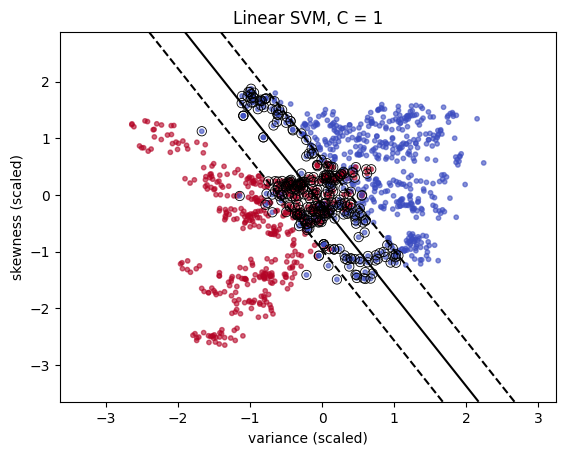

In [ ]:
plot_svm(retrained, "Linear SVM, C = 1")

accuracy: 0.88 | fakes missed: 16 of 122


AttributeError: 'LogisticRegression' object has no attribute 'support_vectors_'

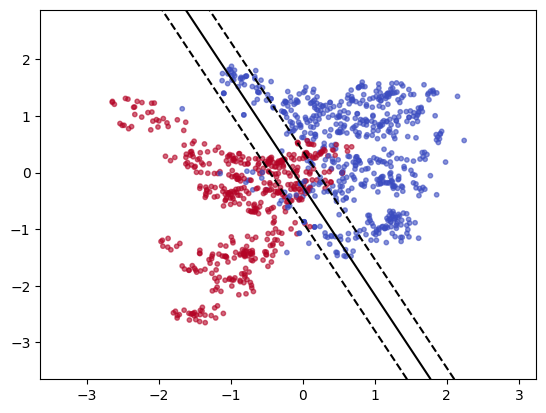

In [ ]:
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression()
log_reg.fit(X_train_scaled, y_train)
report(log_reg)
plot_svm(log_reg, "Log.reg")

In [ ]:
rbf = SVC(kernel='rbf', C=1)
rbf.fit(X_train_scaled, y_train)
report(rbf)

accuracy: 0.924 | fakes missed: 5 of 122


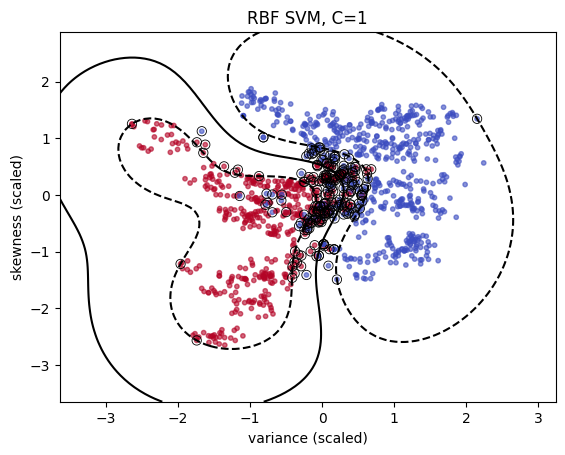

In [ ]:
plot_svm(rbf, "RBF SVM, C=1")

accuracy: 0.578 | fakes missed: 110 of 122


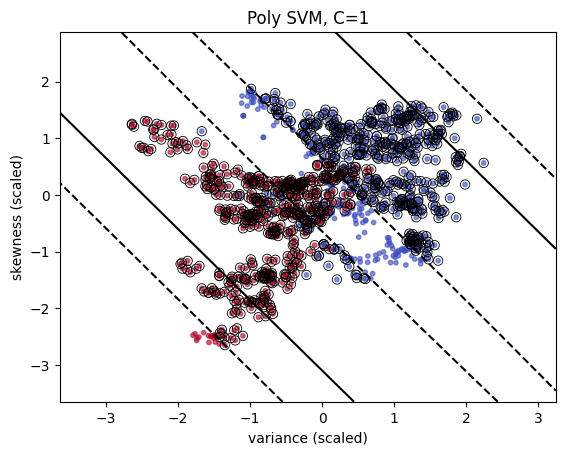

In [ ]:
poly = SVC(kernel='poly', degree=2)
poly.fit(X_train_scaled, y_train)
report(poly)

plot_svm(poly, "Poly SVM, C=1")

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=11)
knn.fit(X_train_scaled, y_train)
report(knn)

accuracy: 0.931 | fakes missed: 3 of 122


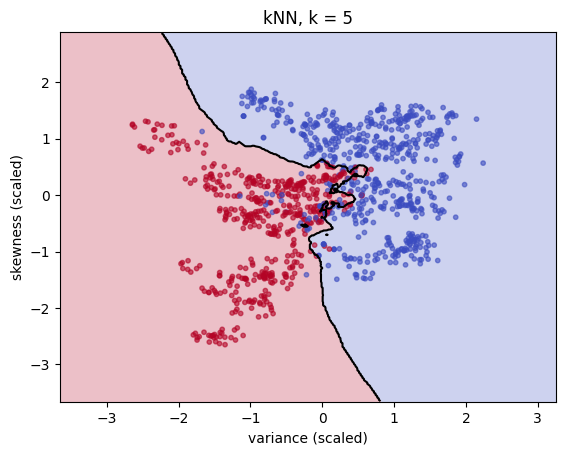

In [ ]:
# kNN has no decision_function or support vectors, so plot_svm won't work.
# Instead: shade the predicted class and draw the 0.5 probability line as the boundary.
def plot_knn(model, title):
    display = DecisionBoundaryDisplay.from_estimator(
        model, X_train_scaled, response_method="predict",
        plot_method="pcolormesh", cmap="coolwarm", alpha=0.25, grid_resolution=300)
    DecisionBoundaryDisplay.from_estimator(
        model, X_train_scaled, response_method="predict_proba",
        plot_method="contour", levels=[0.5], colors="black", linestyles="-",
        grid_resolution=300, ax=display.ax_)
    display.ax_.scatter(X_train_scaled[:, 0], X_train_scaled[:, 1], c=y_train, cmap="coolwarm", s=10, alpha=0.6)
    display.ax_.set(xlabel="variance (scaled)", ylabel="skewness (scaled)", title=title)
    plt.show()

plot_knn(knn, "kNN, k = 5")

In [ ]:
X = notes[['variance',	'skewness'	,'kurtosis',	'entropy']]
y = notes['forged']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
scaler.fit(X_train)   # mu, sig for each column
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
rbf = SVC(kernel='rbf', C=1)
rbf.fit(X_train_scaled, y_train)
report(rbf) # this is test data perfm

accuracy: 1.0 | fakes missed: 0 of 122


In [ ]:
y_pred = rbf.predict(X_test_scaled)

In [ ]:
accuracy_score(y_test, y_pred)

1.0

In [ ]:
# class_weight

# Imbalanced data ?

class_weight = "balanced"
class_weight = {0 : 1, 1 : 99}

## Interview prpe:

1. What does an SVM actually optimise?
2. What is a support vector?
3. What does C control?
4. What is the kernel trick?
5. What does gamma do in an RBF kernel?
6. Why does SVM need feature scaling?
7. SVM vs logistic regression?
8. When would you not use an SVM?
9. How does SVM handle more than two classes?
10. What is the difference between a hard and a soft margin?
11. Is SVM sensitive to outliers?
12. Can SVM do regression?